## Add BioVariables to the **Final Dataset** and convert to **Annual** ##

In [1]:
import pandas as pd
import geopandas as gpd
import datetime
import math
import numpy as np
import missingno
import json
from statistics import mean
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer
import sys
import rpy2.robjects as robjects
import rpy2.ipython.html
from rpy2.robjects.packages import importr

rpy2.ipython.html.init_printing()

sys.path.insert(0, "../../../../Modules")

from utils import *


enc = 'utf-8'
dec = 'greek8'

pd.options.display.max_columns = None
pd.options.display.max_rows = 20
#pd.options.display.float_format = lambda x: '%.6f' % x

c:\Users\dimit\Python Virtual Environments\noa_eywa\Lib\site-packages\rpy2\robjects\packages.py:367: UserWarning: The symbol 'quartz' is not in this R namespace/package.
  warnings.warn(


In [2]:
NUTS0 = 'GR'
NUTS2 = 'Attica'
NUTS2_ID = 'EL30'

In [3]:
dataset_previous = pd.read_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_NUTS3_2009_2023.csv", encoding = enc)
dataset_previous = dataset_previous[dataset_previous.year.isin([2020, 2021, 2022, 2023])].copy()
dataset_previous.reset_index(drop=True, inplace=True)

dataset_previous.head()

,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_night_mean,lst_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,mosq_pred_acc,mosq_pred_mean,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,monthly_lst_min,monthly_lst_max,monthly_acc_prec,cases,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,MIO_EUR,L_TOTAL,UNL_TOTAL
0,2020-01,EL30,αττικη,EL301,βορειος τομεας αθηνων,23.825080,38.055971,1,2020,0.253212,0.103824,-0.221203,-0.103824,0.258404,0.131889,-0.225504,-0.131889,0.041874,0.031281,0.032810,0.031281,11.185355,4.162774,7.674065,11.185355,NaN,NaN,NaN,4.162774,NaN,NaN,NaN,7.674065,NaN,NaN,NaN,2.224000,33.999811,34.202747,68.882866,68.944001,762.266667,24.589247,12596.173352,1653.260278,7.066667,199.653520,293.515429,186.164165,0.000000,11.320098,6975.099311,9.886334,2,158.038271,190.198124,179.915914,0.0,1.000000,15103.584543,3887.958042,14,242.913089,460.563721,193.437501,0.000000,79.730978,2296.456415,1184.432609,4.682287,23.874457,92.528119,3.668097,0.00000,21.863192,22,9,20,13,13,10,8,9,2,1.130000,13.210000,68.944001,0,19.583333,19.666667,45.736434,890.309786,43.0,0.0,43.0,9.000000,30.166667,30.166667,9.000000,968.0,253.0,6.0,87.821436,398.0,76.0,84.0,398.0,41805.0,158226.0,57213.0,257244.0,39597.0,198622.0,76804.0,315023.0,14623.02,2360.0,3237.0
1,2020-01,EL30,αττικη,EL302,δυτικος τομεας αθηνων,23.686502,38.024894,1,2020,0.084205,0.055535,-0.079428,-0.055535,0.107850,0.062579,-0.096997,-0.062579,0.059531,0.042527,0.052829,0.042527,12.436194,4.848323,8.642258,12.436194,NaN,NaN,NaN,4.848323,NaN,NaN,NaN,8.642258,NaN,NaN,NaN,2.083964,36.759617,36.940945,64.596437,64.602889,928.000000,29.935484,7495.493496,2041.783345,2.800000,135.961772,107.413199,175.185410,0.000000,5.799639,5369.544043,863.918625,1,124.980862,72.025314,168.746576,0.0,2.741869,9092.468792,3043.444411,5,157.020761,152.212002,180.041979,0.000000,9.259888,1549.348962,1081.112134,1.788854,12.696343,30.830096,4.405654,0.00000,2.978368,1,9,1,13,13,10,8,9,2,0.898000,14.402000,64.602889,0,21.041667,20.416667,46.401515,895.051632,44.0,0.0,44.0,9.833333,31.333333,31.333333,9.833333,983.0,276.0,4.0,92.570477,404.0,90.0,90.0,404.0,37955.0,155766.0,38427.0,232148.0,35612.0,166190.0,51023.0,252825.0,5159.56,1226.0,3024.0
2,2020-01,EL30,αττικη,EL303,κεντρικος τομεας αθηνων,23.757527,37.973503,1,2020,0.141076,0.139038,-0.096965,-0.139038,0.141437,0.194846,-0.102865,-0.194846,0.063907,0.056003,0.059944,0.056003,11.401097,4.867484,8.134290,11.401097,NaN,NaN,NaN,4.867484,NaN,NaN,NaN,8.134290,NaN,NaN,NaN,1.963237,36.447092,36.696161,60.787762,60.860334,766.500000,24.725806,7451.460209,1907.131239,7.200000,218.497003,207.330391,190.939862,0.000000,2.773017,5491.611975,467.065216,3,162.183002,68.022695,183.011169,0.0,1.000000,9901.346815,4576.388472,14,257.169814,553.363377,208.832872,0.000000,5.152035,1461.964111,1273.662642,4.211096,30.940738,13

In [4]:
dataset_monthly = pd.read_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_NUTS3_2024.csv", encoding = enc)
dataset_monthly.head()

,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_night_mean,lst_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,mosq_pred_acc,mosq_pred_mean,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,monthly_lst_min,monthly_lst_max,monthly_acc_prec,cases,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,MIO_EUR,L_TOTAL,UNL_TOTAL
0,2024-01,EL30,αττικη,EL301,βορειος τομεας αθηνων,23.825080,38.055971,1,2024,0.249087,0.123696,-0.231308,-0.123696,0.246233,0.158698,-0.226363,-0.158698,0.039974,0.028491,0.031608,0.028491,11.833484,7.042301,9.437892,11.833484,15.167149,18.239548,26.853778,7.042301,8.088161,9.059548,14.650667,9.437892,11.627655,13.649548,20.752222,3.913518,29.682600,50.063076,117.341162,121.319052,5376.666667,173.440860,12596.173352,1653.260278,7.066667,199.653520,293.515429,186.164165,0.000000,11.320098,6975.099311,9.886334,2,158.038271,190.198124,179.915914,0.0,1.000000,15103.584543,3887.958042,14,242.913089,460.563721,193.437501,0.000000,79.730978,2296.456415,1184.432609,4.682287,23.874457,92.528119,3.668097,0.00000,21.863192,22,9,20,13,13,10,8,9,2,2.624667,16.636667,121.319052,0,21.0000,19.250,49.358974,909.081169,41.0,2.0,39.0,11.500000,30.500000,30.500000,11.500000,611.0,171.0,0.0,90.185671,420.0,0.0,0.0,420.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-01,EL30,αττικη,EL302,δυτικος τομεας αθηνων,23.686502,38.024894,1,2024,0.102331,0.022448,-0.126808,-0.022448,0.125197,0.047598,-0.137139,-0.047598,0.058575,0.030247,0.040470,0.030247,13.915032,7.783935,10.849484,13.915032,16.596483,19.168194,28.569200,7.783935,9.503655,10.866774,16.326000,10.849484,13.050069,15.017484,22.447600,3.474230,29.121529,46.517285,104.891998,107.701138,12014.400000,387.561290,7495.493496,2041.783345,2.800000,135.961772,107.413199,175.185410,0.000000,5.799639,5369.544043,863.918625,1,124.980862,72.025314,168.746576,0.0,2.741869,9092.468792,3043.444411,5,157.020761,152.212002,180.041979,0.000000,9.259888,1549.348962,1081.112134,1.788854,12.696343,30.830096,4.405654,0.00000,2.978368,1,9,1,13,13,10,8,9,2,1.650000,17.514000,107.701138,0,22.8125,19.125,45.535714,1025.021777,43.0,1.0,42.0,11.833333,33.333333,33.333333,11.833333,639.0,178.0,0.0,90.923187,435.0,0.0,0.0,435.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2024-01,EL30,αττικη,EL303,κεντρικος τομεας αθηνων,23.757527,37.973503,1,2024,0.167139,0.079421,-0.136629,-0.079421,0.183724,0.093767,-0.149276,-0.093767,0.081446,0.049275,0.073039,0.049275,12.635161,7.748065,10.191613,12.635161,15.306069,18.595613,27.249400,7.748065,9.145862,10.398774,15.664000,10.191613,12.225966,14.497194,21.456700,3.144156,18.877301,28.153147,94.893039,97.468831,10429.200000,336.425806,7451.460209,1907.131239,7.200000,218.497003,207.330391,190.939862,0.000000,2.773017,5491.611975,467.065216,3,162.183002,68.022695,183.011169,0.0,1.000000,9901.346815,4576.388472,14,257.169814,553.363377,

In [5]:
merged_df = pd.concat([dataset_previous, dataset_monthly], axis=0)
merged_df.reset_index(drop=True, inplace=True)

In [6]:
merged_df

,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_night_mean,lst_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,mosq_pred_acc,mosq_pred_mean,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,monthly_lst_min,monthly_lst_max,monthly_acc_prec,cases,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,MIO_EUR,L_TOTAL,UNL_TOTAL
0,2020-01,EL30,αττικη,EL301,βορειος τομεας αθηνων,23.825080,38.055971,1,2020,0.253212,0.103824,-0.221203,-0.103824,0.258404,0.131889,-0.225504,-0.131889,0.041874,0.031281,0.032810,0.031281,11.185355,4.162774,7.674065,11.185355,NaN,NaN,NaN,4.162774,NaN,NaN,NaN,7.674065,NaN,NaN,NaN,2.224000,33.999811,34.202747,68.882866,68.944001,762.266667,24.589247,12596.173352,1653.260278,7.066667,199.653520,293.515429,186.164165,0.000000,11.320098,6975.099311,9.886334,2,158.038271,190.198124,179.915914,0.0,1.000000,15103.584543,3887.958042,14,242.913089,460.563721,193.437501,0.000000,79.730978,2296.456415,1184.432609,4.682287,23.874457,92.528119,3.668097,0.000000,21.863192,22,9,20,13,13,10,8,9,2,1.130000,13.210000,68.944001,0,19.583333,19.666667,45.736434,890.309786,43.0,0.0,43.0,9.000000,30.166667,30.166667,9.000000,968.0,253.0,6.0,87.821436,398.0,76.0,84.0,398.0,41805.0,158226.0,57213.0,257244.0,39597.0,198622.0,76804.0,315023.0,14623.02,2360.0,3237.0
1,2020-01,EL30,αττικη,EL302,δυτικος τομεας αθηνων,23.686502,38.024894,1,2020,0.084205,0.055535,-0.079428,-0.055535,0.107850,0.062579,-0.096997,-0.062579,0.059531,0.042527,0.052829,0.042527,12.436194,4.848323,8.642258,12.436194,NaN,NaN,NaN,4.848323,NaN,NaN,NaN,8.642258,NaN,NaN,NaN,2.083964,36.759617,36.940945,64.596437,64.602889,928.000000,29.935484,7495.493496,2041.783345,2.800000,135.961772,107.413199,175.185410,0.000000,5.799639,5369.544043,863.918625,1,124.980862,72.025314,168.746576,0.0,2.741869,9092.468792,3043.444411,5,157.020761,152.212002,180.041979,0.000000,9.259888,1549.348962,1081.112134,1.788854,12.696343,30.830096,4.405654,0.000000,2.978368,1,9,1,13,13,10,8,9,2,0.898000,14.402000,64.602889,0,21.041667,20.416667,46.401515,895.051632,44.0,0.0,44.0,9.833333,31.333333,31.333333,9.833333,983.0,276.0,4.0,92.570477,404.0,90.0,90.0,404.0,37955.0,155766.0,38427.0,232148.0,35612.0,166190.0,51023.0,252825.0,5159.56,1226.0,3024.0
2,2020-01,EL30,αττικη,EL303,κεντρικος τομεας αθηνων,23.757527,37.973503,1,2020,0.141076,0.139038,-0.096965,-0.139038,0.141437,0.194846,-0.102865,-0.194846,0.063907,0.056003,0.059944,0.056003,11.401097,4.867484,8.134290,11.401097,NaN,NaN,NaN,4.867484,NaN,NaN,NaN,8.134290,NaN,NaN,NaN,1.963237,36.447092,36.696161,60.787762,60.860334,766.500000,24.725806,7451.460209,1907.131239,7.200000,218.497003,207.330391,190.939862,0.000000,2.773017,5491.611975,467.065216,3,162.183002,68.022695,183.011169,0.0,1.000000,9901.346815,4576.388472,14,257.169814,553.363377,208.832872,0.000000,5.152035,1461.964111,1273.662642,4.211096,30.940738,

<Axes: >

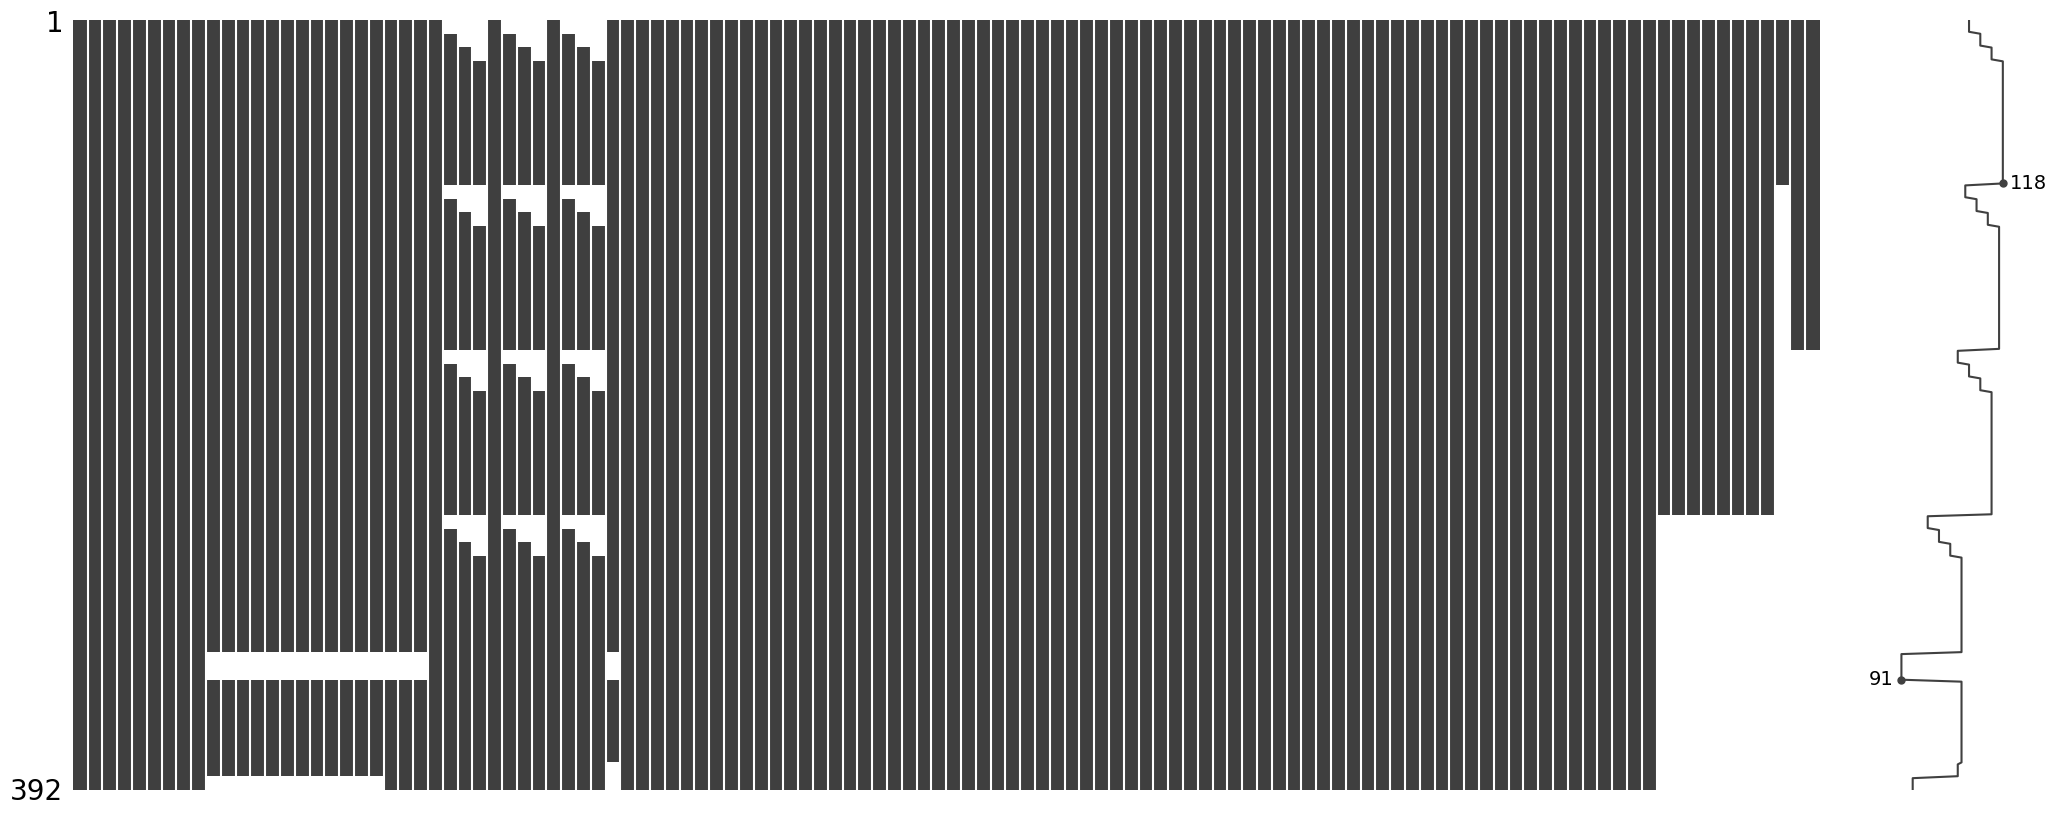

In [7]:
missingno.matrix(merged_df)

In [8]:
imputer = KNNImputer()

knn_imputer_columns = ['x', 'y', 'year', 'M_Y_LT15']

temp_df = merged_df[knn_imputer_columns]

imputed_data = pd.DataFrame(imputer.fit_transform(temp_df), columns = temp_df.columns)

imputed_columns = ['M_Y_LT15']

merged_df[imputed_columns] = imputed_data[imputed_columns]

In [9]:
imputer = KNNImputer()

knn_imputer_columns = ['x', 'y', 'year', 'M_Y15-64']

temp_df = merged_df[knn_imputer_columns]

imputed_data = pd.DataFrame(imputer.fit_transform(temp_df), columns = temp_df.columns)

imputed_columns = ['M_Y15-64']

merged_df[imputed_columns] = imputed_data[imputed_columns]

In [10]:
imputer = KNNImputer()

knn_imputer_columns = ['x', 'y', 'year', 'M_Y_GE65']

temp_df = merged_df[knn_imputer_columns]

imputed_data = pd.DataFrame(imputer.fit_transform(temp_df), columns = temp_df.columns)

imputed_columns = ['M_Y_GE65']

merged_df[imputed_columns] = imputed_data[imputed_columns]

In [11]:
imputer = KNNImputer()

knn_imputer_columns = ['x', 'y', 'year', 'M_TOTAL']

temp_df = merged_df[knn_imputer_columns]

imputed_data = pd.DataFrame(imputer.fit_transform(temp_df), columns = temp_df.columns)

imputed_columns = ['M_TOTAL']

merged_df[imputed_columns] = imputed_data[imputed_columns]

In [12]:
imputer = KNNImputer()

knn_imputer_columns = ['x', 'y', 'year', 'F_Y_LT15']

temp_df = merged_df[knn_imputer_columns]

imputed_data = pd.DataFrame(imputer.fit_transform(temp_df), columns = temp_df.columns)

imputed_columns = ['F_Y_LT15']

merged_df[imputed_columns] = imputed_data[imputed_columns]

In [13]:
imputer = KNNImputer()

knn_imputer_columns = ['x', 'y', 'year', 'F_Y15-64']

temp_df = merged_df[knn_imputer_columns]

imputed_data = pd.DataFrame(imputer.fit_transform(temp_df), columns = temp_df.columns)

imputed_columns = ['F_Y15-64']

merged_df[imputed_columns] = imputed_data[imputed_columns]

In [14]:
imputer = KNNImputer()

knn_imputer_columns = ['x', 'y', 'year', 'F_Y_GE65']

temp_df = merged_df[knn_imputer_columns]

imputed_data = pd.DataFrame(imputer.fit_transform(temp_df), columns = temp_df.columns)

imputed_columns = ['F_Y_GE65']

merged_df[imputed_columns] = imputed_data[imputed_columns]

In [15]:
imputer = KNNImputer()

knn_imputer_columns = ['x', 'y', 'year', 'F_TOTAL']

temp_df = merged_df[knn_imputer_columns]

imputed_data = pd.DataFrame(imputer.fit_transform(temp_df), columns = temp_df.columns)

imputed_columns = ['F_TOTAL']

merged_df[imputed_columns] = imputed_data[imputed_columns]

In [16]:
imputer = KNNImputer()

knn_imputer_columns = ['x', 'y', 'year', 'MIO_EUR']

temp_df = merged_df[knn_imputer_columns]

imputed_data = pd.DataFrame(imputer.fit_transform(temp_df), columns = temp_df.columns)

imputed_columns = ['MIO_EUR']

merged_df[imputed_columns] = imputed_data[imputed_columns]

In [17]:
imputer = KNNImputer()

knn_imputer_columns = ['x', 'y', 'year', 'L_TOTAL']

temp_df = merged_df[knn_imputer_columns]

imputed_data = pd.DataFrame(imputer.fit_transform(temp_df), columns = temp_df.columns)

imputed_columns = ['L_TOTAL']

merged_df[imputed_columns] = imputed_data[imputed_columns]

In [18]:
imputer = KNNImputer()

knn_imputer_columns = ['x', 'y', 'year', 'UNL_TOTAL']

temp_df = merged_df[knn_imputer_columns]

imputed_data = pd.DataFrame(imputer.fit_transform(temp_df), columns = temp_df.columns)

imputed_columns = ['UNL_TOTAL']

merged_df[imputed_columns] = imputed_data[imputed_columns]

In [19]:
desired_order = ['dt_placement','NUTS2_ID','NUTS2_NAME','NUTS3_ID','NUTS3_NAME','x','y','month','year',
 'ndvi','ndmi','ndwi','ndbi','ndvi_mean','ndmi_mean','ndwi_mean','ndbi_mean','ndvi_std','ndmi_std','ndwi_std','ndbi_std',
 'lst_day_mean','lst_jan_day_mean','lst_feb_day_mean','lst_mar_day_mean','lst_apr_day_mean',
 'lst_night_mean','lst_jan_night_mean','lst_feb_night_mean','lst_mar_night_mean','lst_apr_night_mean',
 'lst_mean','lst_jan_mean','lst_feb_mean','lst_mar_mean','lst_apr_mean','monthly_lst_min','monthly_lst_max',
 'rainfall_mean','acc_rainfall_1week','acc_rainfall_2week','acc_rainfall_month','acc_rainfall_jan',
 'bio1','bio2','bio3','bio4','bio5','bio6','bio7','bio8','bio9','bio10','bio11','bio12','bio13','bio14','bio15','bio16','bio17','bio18','bio19',
 'mosq_pred_acc','mosq_pred_mean',
 'distance_to_coast','distance_to_river','slope_mean_1km','aspect_mean_200m','elevation_mean_1km','hillshade_mean_1km','fs_area_1km','flow_accu_200m',
 'distance_to_coast_min','distance_to_river_min','slope_mean_1km_min','aspect_mean_200m_min','elevation_mean_1km_min','hillshade_mean_1km_min','fs_area_1km_min','flow_accu_200m_min',
 'distance_to_coast_max','distance_to_river_max','slope_mean_1km_max','aspect_mean_200m_max','elevation_mean_1km_max','hillshade_mean_1km_max','fs_area_1km_max','flow_accu_200m_max',
 'distance_to_coast_std','distance_to_river_std','slope_mean_1km_std','aspect_mean_200m_std','elevation_mean_1km_std','hillshade_mean_1km_std','fs_area_1km_std','flow_accu_200m_std',
 'lc_prop1','lc_prop2','lc_prop3','lc_type1','lc_type2','lc_type3','lc_type4','lc_type5','lw',
 'M_Y_LT15','M_Y15-64','M_Y_GE65','M_TOTAL','F_Y_LT15','F_Y15-64','F_Y_GE65','F_TOTAL','MIO_EUR','L_TOTAL','UNL_TOTAL',
 'cases']

In [20]:
merged_df = merged_df[desired_order].copy()

In [21]:
years = merged_df.year.unique()
months =  merged_df[merged_df.year == 2024].month.unique()
nuts3_units = merged_df.NUTS3_ID.unique()

In [22]:
years

array([2020, 2021, 2022, 2023, 2024], dtype=int64)

In [23]:
months

array([1, 2, 3, 4, 5, 6, 7, 8], dtype=int64)

In [24]:
years[1:]

array([2021, 2022, 2023, 2024], dtype=int64)

In [25]:
data = []

for year in years[1:]:
    for month in months:
        for region in nuts3_units:
            df_regional = merged_df.loc[(merged_df['NUTS3_ID'] == region)].copy()
            df_regional.reset_index(drop = True, inplace = True)

            df_prev_year = df_regional.loc[(df_regional['year'] == year-1)].copy()
            if month == 1:
                df_prev_month = df_regional.loc[(df_regional['year'] == year-1) & (df_regional['month'] == 12)].copy()
            else:
                df_prev_month = df_regional.loc[(df_regional['year'] == year) & (df_regional['month'] == month -1)].copy()

            df_curr_year = df_regional.loc[(df_regional['year'] == year) & (df_regional['month'] == month)].copy()
        
            data.append({'NUTS3_ID': region, 
                        'year': year, 
                        'month': month,
                        'x' : df_curr_year.iloc[0]['x'],
                        'y': df_curr_year.iloc[0]['y'],
                        'ndvi': df_prev_month.iloc[0]['ndvi'],
                        'ndmi': df_prev_month.iloc[0]['ndmi'],
                        'ndwi': df_prev_month.iloc[0]['ndwi'],
                        'ndbi': df_prev_month.iloc[0]['ndbi'],
                        'ndvi_mean': df_prev_month.iloc[0]['ndvi_mean'],
                        'ndmi_mean': df_prev_month.iloc[0]['ndmi_mean'],
                        'ndwi_mean': df_prev_month.iloc[0]['ndwi_mean'],
                        'ndbi_mean': df_prev_month.iloc[0]['ndbi_mean'],
                        'ndvi_std': df_prev_month.iloc[0]['ndvi_std'],
                        'ndmi_std': df_prev_month.iloc[0]['ndmi_std'],
                        'ndwi_std': df_prev_month.iloc[0]['ndwi_std'],
                        'ndbi_std': df_prev_month.iloc[0]['ndbi_std'],

                        'lst_day_mean': df_prev_month.iloc[0]['lst_day_mean'],
                        'lst_jan_day_mean': df_prev_month.iloc[0]['lst_jan_day_mean'],
                        'lst_feb_day_mean': df_prev_month.iloc[0]['lst_feb_day_mean'],
                        'lst_mar_day_mean': df_prev_month.iloc[0]['lst_mar_day_mean'],
                        'lst_apr_day_mean': df_prev_month.iloc[0]['lst_apr_day_mean'],

                        'lst_night_mean': df_prev_month.iloc[0]['lst_night_mean'],
                        'lst_jan_night_mean': df_prev_month.iloc[0]['lst_jan_night_mean'],
                        'lst_feb_night_mean': df_prev_month.iloc[0]['lst_feb_night_mean'],
                        'lst_mar_night_mean': df_prev_month.iloc[0]['lst_mar_night_mean'],
                        'lst_apr_night_mean': df_prev_month.iloc[0]['lst_apr_night_mean'],

                        'lst_mean': df_prev_month.iloc[0]['lst_mean'],
                        'lst_jan_mean': df_prev_month.iloc[0]['lst_jan_mean'],
                        'lst_feb_mean': df_prev_month.iloc[0]['lst_feb_mean'],
                        'lst_mar_mean': df_prev_month.iloc[0]['lst_mar_mean'],
                        'lst_apr_mean': df_prev_month.iloc[0]['lst_apr_mean'],

                        'monthly_lst_min': df_prev_month.iloc[0]['monthly_lst_min'],
                        'monthly_lst_max': df_prev_month.iloc[0]['monthly_lst_max'],

                        'rainfall_mean': df_prev_month.iloc[0]['rainfall_mean'],
                        'acc_rainfall_1week': df_prev_month.iloc[0]['acc_rainfall_1week'],
                        'acc_rainfall_2week': df_prev_month.iloc[0]['acc_rainfall_2week'],
                        'acc_rainfall_month': df_prev_month.iloc[0]['acc_rainfall_month'],
                        'acc_rainfall_jan': df_prev_month.iloc[0]['acc_rainfall_jan'],

                        'mosq_pred_acc': df_prev_month.iloc[0]['mosq_pred_acc'],
                        'mosq_pred_mean': df_prev_month.iloc[0]['mosq_pred_mean'],

                        'bio1': df_prev_year.iloc[0]['bio1'],
                        'bio2': df_prev_year.iloc[0]['bio2'],
                        'bio3': df_prev_year.iloc[0]['bio3'],
                        'bio4': df_prev_year.iloc[0]['bio4'],
                        'bio5': df_prev_year.iloc[0]['bio5'],
                        'bio6': df_prev_year.iloc[0]['bio6'],
                        'bio7': df_prev_year.iloc[0]['bio7'],
                        'bio8': df_prev_year.iloc[0]['bio8'],
                        'bio9': df_prev_year.iloc[0]['bio9'],
                        'bio10': df_prev_year.iloc[0]['bio10'],
                        'bio11': df_prev_year.iloc[0]['bio11'],
                        'bio12': df_prev_year.iloc[0]['bio12'],
                        'bio13': df_prev_year.iloc[0]['bio13'],
                        'bio14': df_prev_year.iloc[0]['bio14'],
                        'bio15': df_prev_year.iloc[0]['bio15'],
                        'bio16': df_prev_year.iloc[0]['bio16'],
                        'bio17': df_prev_year.iloc[0]['bio17'],
                        'bio18': df_prev_year.iloc[0]['bio18'],
                        'bio19': df_prev_year.iloc[0]['bio19'],

                        'lc_prop1': df_prev_year.iloc[0]['lc_prop1'],
                        'lc_prop2': df_prev_year.iloc[0]['lc_prop2'],
                        'lc_prop3': df_prev_year.iloc[0]['lc_prop3'],
                        'lc_type1': df_prev_year.iloc[0]['lc_type1'],
                        'lc_type2': df_prev_year.iloc[0]['lc_type2'],
                        'lc_type3': df_prev_year.iloc[0]['lc_type3'],
                        'lc_type4': df_prev_year.iloc[0]['lc_type4'],
                        'lc_type5': df_prev_year.iloc[0]['lc_type5'],

                        'distance_to_coast': df_prev_year.iloc[0]['distance_to_coast'],
                        'distance_to_river': df_prev_year.iloc[0]['distance_to_river'],
                        'slope_mean_1km': df_prev_year.iloc[0]['slope_mean_1km'],
                        'aspect_mean_200m': df_prev_year.iloc[0]['aspect_mean_200m'],
                        'elevation_mean_1km': df_prev_year.iloc[0]['elevation_mean_1km'],
                        'hillshade_mean_1km': df_prev_year.iloc[0]['hillshade_mean_1km'],
                        'fs_area_1km': df_prev_year.iloc[0]['fs_area_1km'],
                        'flow_accu_200m': df_prev_year.iloc[0]['flow_accu_200m'],

                        'distance_to_coast_min': df_prev_year.iloc[0]['distance_to_coast_min'],
                        'distance_to_river_min': df_prev_year.iloc[0]['distance_to_river_min'],
                        'slope_mean_1km_min': df_prev_year.iloc[0]['slope_mean_1km_min'],
                        'aspect_mean_200m_min': df_prev_year.iloc[0]['aspect_mean_200m_min'],
                        'elevation_mean_1km_min': df_prev_year.iloc[0]['elevation_mean_1km_min'],
                        'hillshade_mean_1km_min': df_prev_year.iloc[0]['hillshade_mean_1km_min'],
                        'fs_area_1km_min': df_prev_year.iloc[0]['fs_area_1km_min'],
                        'flow_accu_200m_min': df_prev_year.iloc[0]['flow_accu_200m_min'],

                        'distance_to_coast_max': df_prev_year.iloc[0]['distance_to_coast_max'],
                        'distance_to_river_max': df_prev_year.iloc[0]['distance_to_river_max'],
                        'slope_mean_1km_max': df_prev_year.iloc[0]['slope_mean_1km_max'],
                        'aspect_mean_200m_max': df_prev_year.iloc[0]['aspect_mean_200m_max'],
                        'elevation_mean_1km_max': df_prev_year.iloc[0]['elevation_mean_1km_max'],
                        'hillshade_mean_1km_max': df_prev_year.iloc[0]['hillshade_mean_1km_max'],
                        'fs_area_1km_max': df_prev_year.iloc[0]['fs_area_1km_max'],
                        'flow_accu_200m_max': df_prev_year.iloc[0]['flow_accu_200m_max'],

                        'distance_to_coast_std': df_prev_year.iloc[0]['distance_to_coast_std'],
                        'distance_to_river_std': df_prev_year.iloc[0]['distance_to_river_std'],
                        'slope_mean_1km_std': df_prev_year.iloc[0]['slope_mean_1km_std'],
                        'aspect_mean_200m_std': df_prev_year.iloc[0]['aspect_mean_200m_std'],
                        'elevation_mean_1km_std': df_prev_year.iloc[0]['elevation_mean_1km_std'],
                        'hillshade_mean_1km_std': df_prev_year.iloc[0]['hillshade_mean_1km_std'],
                        'fs_area_1km_std': df_prev_year.iloc[0]['fs_area_1km_std'],
                        'flow_accu_200m_std': df_prev_year.iloc[0]['flow_accu_200m_std'],

                        'males_lt15': df_prev_year.iloc[0]['M_Y_LT15'],
                        'males_15t64': df_prev_year.iloc[0]['M_Y15-64'],
                        'males_gt65': df_prev_year.iloc[0]['M_Y_GE65'],
                        'males_total': df_prev_year.iloc[0]['M_TOTAL'],
                        'females_lt15': df_prev_year.iloc[0]['F_Y_LT15'],
                        'females_15t64': df_prev_year.iloc[0]['F_Y15-64'],
                        'females_gt65': df_prev_year.iloc[0]['F_Y_GE65'],
                        'females_total': df_prev_year.iloc[0]['F_TOTAL'],
                        'mio_eur': df_prev_year.iloc[0]['MIO_EUR'],
                        'l_total': df_prev_year.iloc[0]['L_TOTAL'],
                        'unl_total': df_prev_year.iloc[0]['UNL_TOTAL'],
                    
                        'cases': df_curr_year.iloc[0]['cases'],
                        })
        
dataset_operational = pd.DataFrame(data)       

In [26]:
merged_df[(merged_df['NUTS3_ID'] == 'EL301') & (merged_df['year'] == 2023)].drop(columns=['NUTS2_ID','NUTS2_NAME','NUTS3_NAME'])

,dt_placement,NUTS3_ID,x,y,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_night_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,monthly_lst_min,monthly_lst_max,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,mosq_pred_acc,mosq_pred_mean,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,MIO_EUR,L_TOTAL,UNL_TOTAL,cases
252,2023-01,EL301,23.82508,38.055971,1,2023,0.170173,0.135479,-0.129155,-0.135479,0.170138,0.157140,-0.119331,-0.157140,0.040364,0.043236,0.043990,0.043236,13.179333,13.179333,NaN,NaN,NaN,6.904151,6.904151,NaN,NaN,NaN,10.041742,10.041742,NaN,NaN,NaN,2.639333,16.558000,5.181458,108.850464,121.430822,160.625190,160.625190,20.208333,17.916667,39.814815,854.522284,45.0,0.0,45.0,11.0,30.833333,31.166667,9.666667,553.0,160.0,0.0,115.741879,302.0,11.0,119.0,242.0,1187.866667,38.318280,12596.173352,1653.260278,7.066667,199.65352,293.515429,186.164165,0.0,11.320098,6975.099311,9.886334,2,158.038271,190.198124,179.915914,0.0,1.0,15103.584543,3887.958042,14,242.913089,460.563721,193.437501,0.0,79.730978,2296.456415,1184.432609,4.682287,23.874457,92.528119,3.668097,0.0,21.863192,22,9,20,13,13,10,8,9,2,44236.0,180823.0,57710.0,282769.0,41969.0,197468.0,77919.0,317356.0,14623.02,4048.0,7024.0,0
259,2023-02,EL301,23.82508,38.055971,2,2023,0.182557,0.135146,-0.165038,-0.135146,0.184829,0.139974,-0.163787,-0.139974,0.034102,0.034829,0.032059,0.034829,13.241571,13.179333,13.241571,NaN,NaN,4.908238,6.904151,4.908238,NaN,NaN,9.074905,10.041742,9.074905,NaN,NaN,-0.750000,18.339333,2.959243,17.382840,17.382840,85.017648,243.484000,20.208333,17.916667,39.814815,854.522284,45.0,0.0,45.0,11.0,30.833333,31.166667,9.666667,553.0,160.0,0.0,115.741879,302.0,11.0,119.0,242.0,439.800000,15.707143,12596.173352,1653.260278,7.066667,199.65352,293.515429,186.164165,0.0,11.320098,6975.099311,9.886334,2,158.038271,190.198124,179.915914,0.0,1.0,15103.584543,3887.958042,14,242.913089,460.563721,193.437501,0.0,79.730978,2296.456415,1184.432609,4.682287,23.874457,92.528119,3.668097,0.0,21.863192,22,9,20,13,13,10,8,9,2,44236.0,180823.0,57710.0,282769.0,41969.0,197468.0,77919.0,317356.0,14623.02,4048.0,7024.0,0
266,2023-03,EL301,23.82508,38.055971,3,2023,0.226888,0.053548,-0.231416,-0.053548,0.218573,0.074547,-0.215565,-0.074547,0.039912,0.026412,0.039497,0.026412,18.026946,13.179333,13.241571,18.026946,NaN,8.618559,6.904151,4.908238,8.618559,NaN,13.322753,10.041742,9.074905,13.322753,NaN,4.656667,26.532667,1.942191,1.666814,5.194508,60.064842,303.691918,20.208333,17.916667,39.814815,854.522284,45.0,0.0,45.0,11.0,30.833333,31.166667,9.666667,553.0,160.0,0.0,115.741879,302.0,11.0,119.0,242.0,1063.133333,34.294624,12596.173352,1653.260278,7.066667,199.65352,293.515429,186.164165,0.0,11.320098,6975.099311,9.886334,2,158.038271,190.198124,179.915914,0.0,1.0,15103.584543,3887.958042,14,242.913089,460.563721,193.437501,0.0,79.730978,2296.456415,1184.432609,4.682287,23.874457,9

In [27]:
dataset_operational[(dataset_operational['NUTS3_ID'] == 'EL301') & (dataset_operational['year'] == 2024)]

,NUTS3_ID,year,month,x,y,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_night_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,monthly_lst_min,monthly_lst_max,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,mosq_pred_acc,mosq_pred_mean,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,males_lt15,males_15t64,males_gt65,males_total,females_lt15,females_15t64,females_gt65,females_total,mio_eur,l_total,unl_total,cases
168,EL301,2024,1,23.82508,38.055971,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13.179333,13.241571,18.026946,18.026946,NaN,6.904151,4.908238,8.618559,8.618559,NaN,10.041742,9.074905,13.322753,13.322753,4.539340,18.614557,NaN,0.000000,0.000000,0.000000,557.585678,93.866667,3.027957,20.208333,17.916667,39.814815,854.522284,45.0,0.0,45.0,11.0,30.833333,31.166667,9.666667,553.0,160.0,0.0,115.741879,302.0,11.0,119.0,242.0,22,9,20,13,13,10,8,9,12596.173352,1653.260278,7.066667,199.65352,293.515429,186.164165,0.0,11.320098,6975.099311,9.886334,2,158.038271,190.198124,179.915914,0.0,1.0,15103.584543,3887.958042,14,242.913089,460.563721,193.437501,0.0,79.730978,2296.456415,1184.432609,4.682287,23.874457,92.528119,3.668097,0.0,21.863192,44236.0,180823.0,57710.0,282769.0,41969.0,197468.0,77919.0,317356.0,14623.02,4048.0,7024.0,0
175,EL301,2024,2,23.82508,38.055971,0.249087,0.123696,-0.231308,-0.123696,0.246233,0.158698,-0.226363,-0.158698,0.039974,0.028491,0.031608,0.028491,11.833484,11.833484,15.167149,18.239548,26.853778,7.042301,7.042301,8.088161,9.059548,14.650667,9.437892,9.437892,11.627655,13.649548,20.752222,2.624667,16.636667,3.913518,29.682600,50.063076,117.341162,121.319052,5376.666667,173.440860,20.208333,17.916667,39.814815,854.522284,45.0,0.0,45.0,11.0,30.833333,31.166667,9.666667,553.0,160.0,0.0,115.741879,302.0,11.0,119.0,242.0,22,9,20,13,13,10,8,9,12596.173352,1653.260278,7.066667,199.65352,293.515429,186.164165,0.0,11.320098,6975.099311,9.886334,2,158.038271,190.198124,179.915914,0.0,1.0,15103.584543,3887.958042,14,242.913089,460.563721,193.437501,0.0,79.730978,2296.456415,1184.432609,4.682287,23.874457,92.528119,3.668097,0.0,21.863192,44236.0,180823.0,57710.0,282769.0,41969.0,197468.0,77919.0,317356.0,14623.02,4048.0,7024.0,0
182,EL301,2024,3,23.82508,38.055971,0.228169,0.101152,-0.222536,-0.101152,0.209502,0.150995,-0.189110,-0.150995,0.034636,0.025634,0.029816,0.025634,15.167149,11.833484,15.167149,18.239548,26.853778,8.088161,7.042301,8.088161,9.059548,14.650667,11.627655,9.437892,11.627655,13.649548,20.752222,2.243333,18.363333,4.441161,87.894409,102.998886,128.797071,250.112727,6009.866667,207.236782,20.208333,17.916667,39.814815,854.522284,45.0,0.0,45.0,11.0,30.833333,31.166667,9.666667,553.0,160.0,0.0,115.741879,302.0,11.0,119.0,242.0,22,9,20,13,13,10,8,9,12596.173352,1653.260278,7.066667,199.65352,293.515429,186.164165,0.0,11.320098,6975.099311,9.886334,2,158.038271,190.198124,179.915914,0.0,1.0,15103.584543,3887.958042,14,242.913089,460.563721,193.437501,0.0,79.730978,2296.456415,1184.43260

In [28]:
dataset_operational = dataset_operational[dataset_operational.year == 2024]

<Axes: >

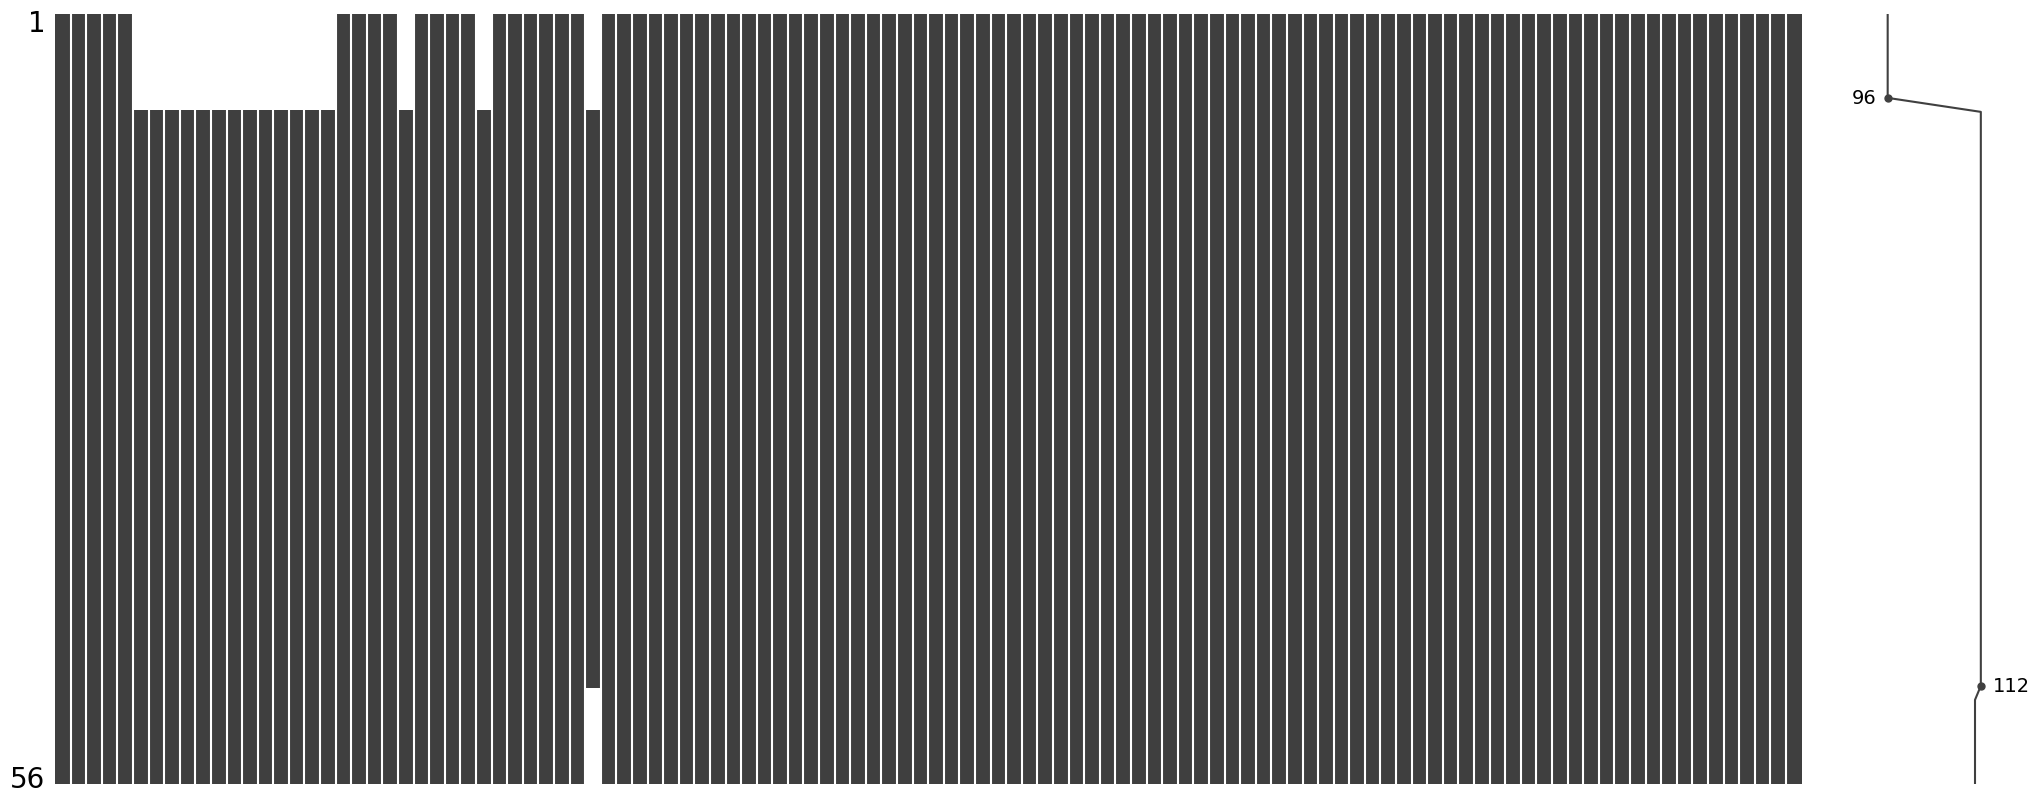

In [29]:
missingno.matrix(dataset_operational)

In [30]:
missing = describe_dataframe(dataset_operational, remove_zeros=True)
missing

,Column,Missing
5,ndvi,12.5
6,ndmi,12.5
7,ndwi,12.5
8,ndbi,12.5
9,ndvi_mean,12.5
10,ndmi_mean,12.5
11,ndwi_mean,12.5
12,ndbi_mean,12.5
13,ndvi_std,12.5
14,ndmi_std,12.5


<Axes: >

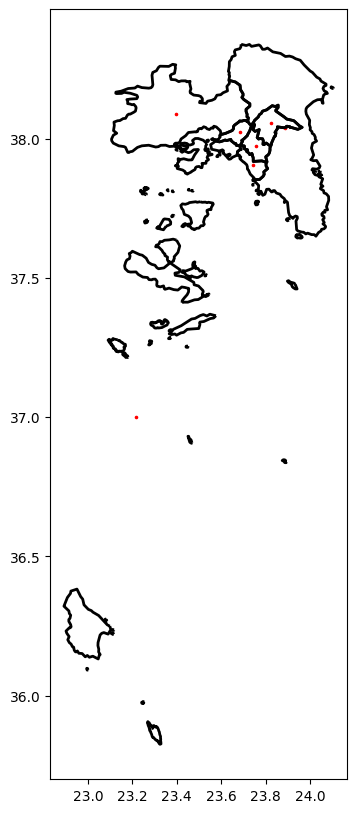

In [31]:
## Reading shapefiles from Greece

greece_nuts3_gdf = gpd.read_file(f"../../../../Europe Shapefiles/Greece/data/EL_Whole.shp",  encoding=enc)

greece_nuts3_gdf = greece_nuts3_gdf.to_crs(epsg=4326)

nuts3_gdf = greece_nuts3_gdf[greece_nuts3_gdf['NUTS2_ID'] == f'{NUTS2_ID}']

nuts3_points = gpd.GeoDataFrame(dataset_previous[['NUTS3_ID']], geometry=gpd.points_from_xy(dataset_previous.x, dataset_previous.y))

ax = nuts3_points.head(7).plot(markersize=2.5, figsize=(10, 10), color='red')
nuts3_gdf.plot(facecolor="none", edgecolor='black', ax=ax, lw=2)

In [32]:
dataset_operational.to_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_OP_2024.csv", encoding = enc, index = False)